<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\1535625481.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 0| Loss = 10.016581535339355| Lnorm=0.9998373985290527| norm=8.128717308863997e-05
Epoch 500| Loss = 3.497573925415054e-05| Lnorm=8.079098279267782e-09| norm=1.0000898838043213
Epoch 1000| Loss = 1.5203905604721513e-05| Lnorm=4.604316927725449e-12| norm=0.9999978542327881
Epoch 1500| Loss = 9.683554708317388e-06| Lnorm=1.4784973245696165e-10| norm=1.0000121593475342
Epoch 2000| Loss = 8.035505743464455e-06| Lnorm=5.1159076974727213e-11| norm=1.000007152557373
Epoch 2500| Loss = 6.814706011937233e-06| Lnorm=8.425615760643268e-11| norm=1.0000091791152954
Epoch 3000| Loss = 4.713299131253734e-05| Lnorm=1.126100102055716e-07| norm=1.0003355741500854
Epoch 3500| Loss = 1.2348950804152992e-05| Lnorm=4.090043503879315e-08| norm=0.9997977614402771
Epoch 4000| Loss = 0.00017831883451435715| Lnorm=5.520957984117558e-07| norm=1.00074303150177
Epoch 4500| Loss = 4.221018116368214e-06| Lnorm=3.916866830877552e-11| norm=0.9999937415122986
6.420919817173854e-05
0.021722793579101562


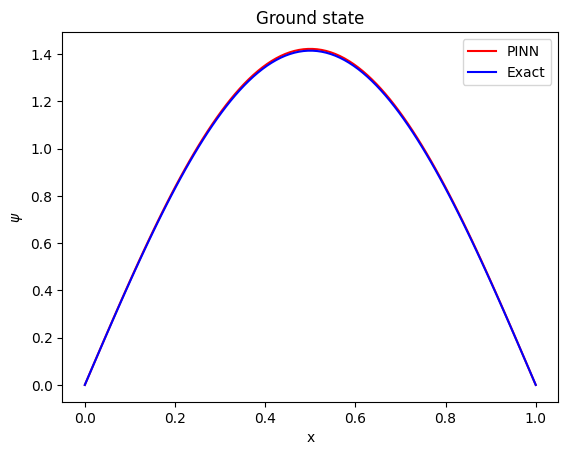

PDE Loss      : 8.272570266854018e-05
Max Residual  : 0.023452460765838623
Norm          : 1.0006741285324097


In [61]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =pde_loss + 10*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='red')
plt.plot(x_np,psi_exact,label='Exact',color='blue')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('Ground state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())

Epoch 0| Loss = 299998.71875| Lnorm=0.9999920129776001| norm=3.975978415837744e-06


<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\2144664898.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 500| Loss = 184515.890625| Lnorm=0.1696312576532364| norm=0.5881368517875671
Epoch 1000| Loss = 156236.375| Lnorm=0.09516043961048126| norm=0.6915191411972046
Epoch 1500| Loss = 80443.3671875| Lnorm=0.051067519932985306| norm=0.7740187644958496
Epoch 2000| Loss = 1463.28271484375| Lnorm=1.8480246581020765e-05| norm=0.9957011342048645
Epoch 2500| Loss = 1265.14404296875| Lnorm=4.847903710469836e-06| norm=0.9977982044219971
Epoch 3000| Loss = 1185.683349609375| Lnorm=3.898035174643155e-06| norm=0.99802565574646
Epoch 3500| Loss = 49.04094314575195| Lnorm=1.9403391888772603e-06| norm=0.9986070394515991
Epoch 4000| Loss = 44.35566329956055| Lnorm=3.072912932111649e-06| norm=1.0017529726028442
Epoch 4500| Loss = 5.382516384124756| Lnorm=1.0852733112187707e-07| norm=0.9996705651283264
0.008551965467631817
0.4310283660888672


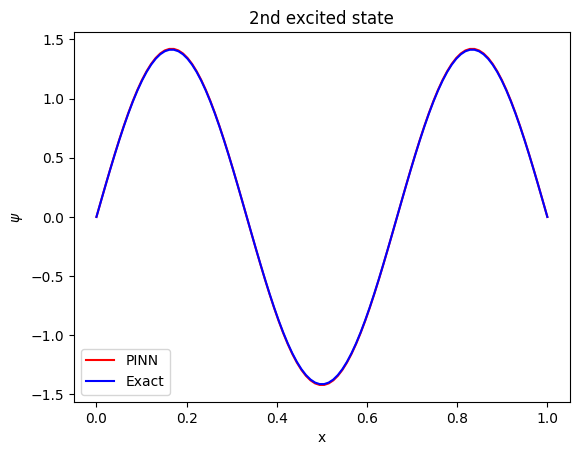

PDE Loss      : 0.008554545231163502
Max Residual  : 0.4279756546020508
Norm          : 0.9999812841415405


In [62]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=9*torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =100*pde_loss + 300000*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(3*np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='red')
plt.plot(x_np,psi_exact,label='Exact',color='blue')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('2nd excited state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())


<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_12096\371120829.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


Epoch 0| Loss = 20009.548828125| Lnorm=0.9996139407157898| norm=0.00019307972979731858
Epoch 500| Loss = 5676.51904296875| Lnorm=0.01046380028128624| norm=0.8977072834968567
Epoch 1000| Loss = 1649.6632080078125| Lnorm=0.0017644352046772838| norm=0.957994818687439
Epoch 1500| Loss = 1601.1368408203125| Lnorm=0.0016745260218158364| norm=0.9590790271759033
Epoch 2000| Loss = 1585.7115478515625| Lnorm=0.0016517352778464556| norm=0.9593584537506104
Epoch 2500| Loss = 1576.637939453125| Lnorm=0.0016213345807045698| norm=0.9597342014312744
Epoch 3000| Loss = 1571.30078125| Lnorm=0.001632104511372745| norm=0.9596006870269775
Epoch 3500| Loss = 1567.683349609375| Lnorm=0.0016014516586437821| norm=0.9599818587303162
Epoch 4000| Loss = 1565.404541015625| Lnorm=0.0015947084175422788| norm=0.9600661993026733
Epoch 4500| Loss = 1568.0888671875| Lnorm=0.0015103932237252593| norm=0.9611362218856812
15.320898056030273
18.328781127929688


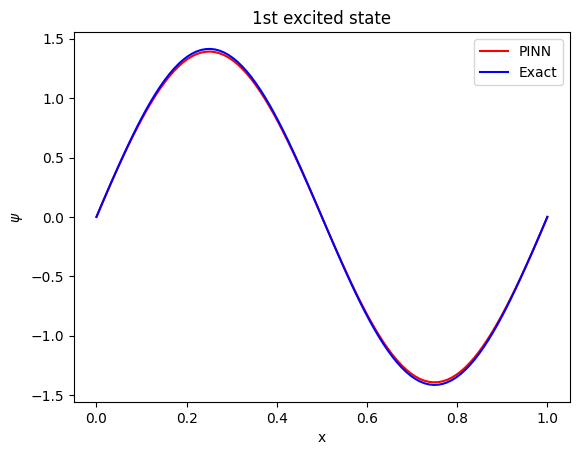

PDE Loss      : 15.331989288330078
Max Residual  : 18.3288631439209
Norm          : 0.9605481624603271


In [60]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import numpy as np
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1,64)
        self.fc2= nn.Linear(64,100)
        self.fc3=nn.Linear(100,64)
        self.fc4=nn.Linear(64,1)

    def forward (self,x):
        x=torch.tanh(self.fc1(x))
        x=torch.tanh(self.fc2(x))
        x=torch.tanh(self.fc3(x))
        x= self.fc4(x)
        return(x)

def derivative (y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

def psi ( model,x):
    return x*(1-x)*model(x)

x=torch.linspace(0,1,100).reshape(-1,1)
x.requires_grad_(True)

model=Net()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
E=4*torch.pi**2

for epoch in range(5000):
    optimizer.zero_grad()
    psi_pred= psi(model,x)
    psi_x = derivative(psi_pred,x)
    psi_xx= derivative(psi_x,x)

    # Loss calculation 
    r=psi_xx+E*psi_pred
    pde_loss=torch.mean(r**2)
    norm =torch.mean(psi_pred**2)

    Lnorm =(norm-1)**2

    loss =100*pde_loss + 20000*Lnorm
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}| Loss = {loss.item()}| Lnorm={Lnorm.item()}| norm={norm.item()}")

        
with torch.no_grad():
    psi_nn=psi(model,x).numpy()
x_np= x.detach().numpy()

psi_exact=np.sqrt(2)*np.sin(2*np.pi*x_np)

if np.sum(psi_nn*psi_exact)<0:
    psi_nn=-psi_nn
    
print(torch.mean(r**2).item())
print(torch.max(torch.abs(r)).item())
plt.plot(x_np,psi_nn,label='PINN',color='red')
plt.plot(x_np,psi_exact,label='Exact',color='blue')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.title('1st excited state')
plt.legend()
plt.show()
psi_pred = psi(model, x)

psi_x = derivative(psi_pred, x)
psi_xx = derivative(psi_x, x)

r = psi_xx + E*psi_pred

print("PDE Loss      :", torch.mean(r**2).item())
print("Max Residual  :", torch.max(torch.abs(r)).item())
print("Norm          :", torch.mean(psi_pred**2).item())
